<a href="https://colab.research.google.com/github/nguyenanhtienabcd/M09_RROJ_Emoji_Image_Generation/blob/feature%2FProjec-emoji-generation/m09_project_emoji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project sinh ảnh Emoji

## Thu thập dữ liệu từ trang web

In [ ]:
%%bash
# Ubuntu hiện không phân phối Chromium ngoài snap, vì vậy ta thêm repository Debian Buster
# Tham khảo: https://askubuntu.com/questions/1204571/how-to-install-chromium-without-snap

# Thêm repository Debian Buster
cat << "EOF" | sudo tee /etc/apt/sources.list.d/debian.list
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-buster.gpg] http://deb.debian.org/debian buster main
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-buster-updates.gpg] http://deb.debian.org/debian buster-updates main
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-security-buster.gpg] http://deb.debian.org/debian-security buster/updates main
EOF

# Thêm khóa công khai cần thiết từ keyserver của Ubuntu
sudo apt-key adv --keyserver keyserver.ubuntu.com --recv-keys DCC9EFBF77E11517
sudo apt-key adv --keyserver keyserver.ubuntu.com --recv-keys 648ACFD622F3D138
sudo apt-key adv --keyserver keyserver.ubuntu.com --recv-keys 112695A0E562B32A

# Xuất các khóa và lưu vào keyrings tương ứng
sudo apt-key export 77E11517 | sudo gpg --dearmor -o /usr/share/keyrings/debian-buster.gpg
sudo apt-key export 22F3D138 | sudo gpg --dearmor -o /usr/share/keyrings/debian-buster-updates.gpg
sudo apt-key export E562B32A | sudo gpg --dearmor -o /usr/share/keyrings/debian-security-buster.gpg

# Ưu tiên repository Debian cho các gói liên quan đến Chromium
cat << "EOF" | sudo tee /etc/apt/preferences.d/chromium.pref
Package: *
Pin: release a=eoan
Pin-Priority: 500

Package: *
Pin: origin "deb.debian.org"
Pin-Priority: 300

Package: chromium*
Pin: origin "deb.debian.org"
Pin-Priority: 700
EOF

# Cập nhật danh sách gói và cài đặt Chromium cùng Chromium Driver
sudo apt-get update
sudo apt-get install -y chromium chromium-driver

# Cài đặt thư viện Selenium cho Python
pip install selenium

deb [arch=amd64 signed-by=/usr/share/keyrings/debian-buster.gpg] http://deb.debian.org/debian buster main
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-buster-updates.gpg] http://deb.debian.org/debian buster-updates main
deb [arch=amd64 signed-by=/usr/share/keyrings/debian-security-buster.gpg] http://deb.debian.org/debian-security buster/updates main
Executing: /tmp/apt-key-gpghome.Z6Id7Cc8Zj/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys DCC9EFBF77E11517
Executing: /tmp/apt-key-gpghome.5D2n0ZGbhb/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys 648ACFD622F3D138
Executing: /tmp/apt-key-gpghome.zgMwrDoQtp/gpg.1.sh --keyserver keyserver.ubuntu.com --recv-keys 112695A0E562B32A
Package: *
Pin: release a=eoan
Pin-Priority: 500

Package: *
Pin: origin "deb.debian.org"
Pin-Priority: 300

Package: chromium*
Pin: origin "deb.debian.org"
Pin-Priority: 700
Get:1 http://deb.debian.org/debian buster InRelease [122 kB]
Get:2 http://deb.debian.org/debian buster-updates InRelease [5

gpg: key DCC9EFBF77E11517: public key "Debian Stable Release Key (10/buster) <debian-release@lists.debian.org>" imported
gpg: Total number processed: 1
gpg:               imported: 1
gpg: key DC30D7C23CBBABEE: public key "Debian Archive Automatic Signing Key (10/buster) <ftpmaster@debian.org>" imported
gpg: Total number processed: 1
gpg:               imported: 1
gpg: key 4DFAB270CAA96DFA: public key "Debian Security Archive Automatic Signing Key (10/buster) <ftpmaster@debian.org>" imported
gpg: Total number processed: 1
gpg:               imported: 1
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 26.)
debconf: falling back to frontend: Rea

In [ ]:
import os
import requests
import time
import json
import pandas as pd
import random
import hashlib
import urllib.parse
from io import BytesIO # Changed 'IO' to 'io'
from PIL import Image



from tqdm import tqdm
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException

In [ ]:
# ⏱ Thời gian chờ mặc định
WEBDRIVER_DELAY_TIME_INT = 20   # Thời gian chờ WebDriverWait
TIMEOUT_INT = 20                # Thời gian chờ ngầm định cho driver

# 🛠 Đường dẫn tới ChromeDriver
service = Service(executable_path="/usr/bin/chromedriver")

# ⚙️ Cấu hình trình duyệt Chrome (headless)
chrome_options = webdriver.ChromeOptions ()
chrome_options.add_argument("--headless")                     # Chạy trình duyệt không hiển thị giao diện
chrome_options.add_argument("--no-sandbox")                   # Bỏ sandbox để tránh lỗi khi chạy trong Docker/Linux
chrome_options.add_argument("--disable-dev-shm-usage")        # Tránh lỗi chia sẻ bộ nhớ trong môi trường hạn chế
chrome_options.add_argument("window-size=1920x1080")          # Đặt kích thước cửa sổ mặc định

# (Tùy chọn) Cách khác để bật headless nếu không dùng dòng trên
chrome_options.headless = True

# 🚀 Khởi tạo driver với các tùy chọn trên
driver = webdriver.Chrome(service=service, options=chrome_options)

# ⏳ Thiết lập thời gian chờ mặc định
driver.implicitly_wait(TIMEOUT_INT)                           # Chờ ngầm định khi tìm element
wait = WebDriverWait(driver, WEBDRIVER_DELAY_TIME_INT)        # Chờ có điều kiện (EC)

In [ ]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
import time

def get_image_links_from_page(page_url, driver, wait_time=20):
    """
    Truy cập trang và trích xuất danh sách ảnh (img_url, img_title).
    """
    try:
        driver.get(page_url)

        time.sleep(2)  # Cho trang JS load sơ
        print("[🧪] Kiểm tra HTML đầu trang:")
        print(driver.page_source[:500])  # In thử để debug

        wait = WebDriverWait(driver, wait_time)

        # Chờ đến khi có ít nhất 1 ảnh emoji xuất hiện
        wait.until(EC.presence_of_element_located(
            (By.CSS_SELECTOR, "div.LQY5mtmC img")  # chờ thẻ <img> xuất hiện bên trong block
        ))

        # Lấy danh sách khối emoji
        image_items = driver.find_elements(By.CSS_SELECTOR, "div.LQY5mtmC")

        if not image_items:
            print(f"[⚠️] Trang {page_url} không có ảnh")
            return []  # ✅ đã fix

        image_links = []

        for img_elem in image_items:
            try:
                img_tag = img_elem.find_element(By.CSS_SELECTOR, "img")
                img_url = img_tag.get_attribute("src")
                img_title = img_tag.get_attribute("title")
                if img_url:
                    image_links.append((img_url, img_title))
            except Exception as inner_e:
                print(f"[!] Không thể lấy ảnh từ phần tử: {inner_e}")
                continue

        return image_links

    except TimeoutException:
        print(f"[⏱] Timeout khi chờ load ảnh từ {page_url}")
        return []

    except Exception as e:
        print(f"[❌] Lỗi không xác định tại {page_url}: {type(e).__name__}: {e}")
        return []


In [ ]:
# def get_image_links_from_page(page_url, driver, wait_time=20):
#     """
#     Truy cập trang và trích xuất danh sách ảnh (img_url, img_title).
#     """
#     try:
#         driver.get(page_url)
#         ######
#         time.sleep(2)  # cho trang load sơ trước
#         print("[🧪] Kiểm tra HTML đầu trang:")
#         print(driver.page_source[:500])  # in thử 500 ký tự đầu tiên
#         ######

#         wait = WebDriverWait(driver, wait_time)

#         # Đợi phần tử chính
#         wait.until(EC.presence_of_element_located(
#             (By.CSS_SELECTOR, "div.F5SUE28h.container div.y-5H7US5")
#         ))

#         # Lấy các khối emoji
#         image_items = wait.until(EC.presence_of_all_elements_located(
#             (By.CSS_SELECTOR, "div.LQY5mtmC div.aLnnpRah.text-center")
#         ))

#         if not image_items:
#           print(f"[⚠️] Trang {page_url} không có ảnh")
#           return []

#         image_links = []

#         for img_elem in image_items:
#             try:
#                 # Tìm trực tiếp thẻ <img> trong mỗi block
#                 img_tag = img_elem.find_element(By.CSS_SELECTOR, "div.Mw1EAtrx img, img")
#                 img_url = img_tag.get_attribute("src")
#                 img_title = img_tag.get_attribute("title")

#                 if img_url:
#                     image_links.append((img_url, img_title))

#             except Exception as inner_e:
#                 print(f"[!] Không thể lấy ảnh từ phần tử: {inner_e}")
#                 continue

#         return image_links

#     except TimeoutException:
#         print(f"[⏱] Timeout khi chờ load ảnh từ {page_url}")
#         return []

#     except Exception as e:
#         print(f"[❌] Lỗi không xác định tại {page_url}: {type(e).__name__}: {e}")
#         return []


In [ ]:
# # xây dựng một hàm trích xuất ảnh từ trang web
# # mục đích của hàm này là lấy link ảnh và trả về title cũng như link lấy ảnh
# def get_image_links_from_page(page_url, driver):
#   driver.get(page_url)
#   try:
#     container = wait.until(EC.presence_of_element_located(
#         (By.CSS_SELECTOR, "div.FS5UE28h.container") # Corrected SCC_SELECTOR to CSS_SELECTOR
#     ))
#     image_items = wait.until(EC.presence_of_all_elements_located(
#         (By.CSS_SELECTOR, "div.LQY5mtmC div.aLnnpRah.text - center"))) # Corrected SCC_SELECTOR to CSS_SELECTOR

#     image_links = []
#     for item in image_items:
#       image_div = item.find_element(By.CSS_SELECTOR , "div.Mw1EAtrx img, img") # Corrected SCC_SELECTOR to CSS_SELECTOR
#       img_url = image_div.get_attribute("src")
#       img_title = image_div.get_attribute("title")
#       if img_url:
#         image_links.append((img_url, img_title))

#     return image_links

#   except Exception as e:
#     print(f"Error while trying to extract image: {e}")
#     return []

In [ ]:
# xây dựng một hàm kiểm tra ảnh trùng dựa vào đường dẫn ảnh vói thư viện hashlib
# mục đích là băm nhỏ ảnh thành md5 code và so sánh code của từng ảnh để kiểm tra
# sự giống nhau
def hasj_image_content(url):
  try:
    response = requests.get(url, stream=True)
    if response.status_code == 200:
      return hashlib.md5(response.content).hexdigest()
    else:
      print(f'Error downloadig image from {url}; status: {response.status_code}')
      return None
  except Exception as e:
    print(f"Error with image download for {url}: {e}")
    return None

In [ ]:
# khi quan sát thấy ảnh trong trang web là dạng .webp
# ta cần chuyển định dạng của ảnh từ .webp sang jpg
# .webp – là định dạng ảnh nén mới, nhẹ và chất lượng cao.
# Đây là dữ liệu ảnh dạng nhị phân (binary)

def convert_webp_to_jpg(webp_data):
  img = Image.open(BytesIO(webp_data)) # tạo file giả từ dữ liệu nhị phân
  if img.format == 'WEBP': # kiểm định dạng của ảnh
      if img.mode == 'RGBA':
          img = img.convert('RGB')

      buffer = BytesIO() #là cách nhẹ, nhanh, và sạch sẽ để xử lý ảnh ngay trong bộ nhớ
      img.save(buffer, format="JPEG") # mục điachs là save duex lueeh ảnh jpeg vào buffer
      return buffer.getvalue() # lấy ảnh ra, khi ảnh vẫn trên RAM
  else:
      return webp_data


In [ ]:
# Hàm tải ảnh từ URL và lưu về thư mục chỉ định, có xử lý chuyển đổi WebP → JPEG nếu cần
def download_image(img_url, img_name, folder_path):
    try:
        # Gửi request để tải ảnh, sử dụng stream để không load toàn bộ ngay lập tức
        response = requests.get(img_url, stream=True)

        # Nếu request thành công (mã 200)
        if response.status_code == 200:
            # Tạo đường dẫn file ảnh sau khi tải về
            img_path = os.path.join(folder_path, f"{img_name}")

            # Gọi hàm chuyển đổi từ WebP sang JPEG nếu cần (trả về dữ liệu bytes)
            img_data = convert_webp_to_jpg(response.content) # response.content là kiểu bytes

            # Mở file (file này lưu sẵn với đuôi là .jpg) ở chế độ ghi nhị phân và ghi dữ liệu ảnh vào
            with open(img_path, "wb") as f:
                f.write(img_data)

        else:
            # Nếu server trả về lỗi (ví dụ: 404, 500, ...)
            print(f"Error downloading image from {img_url}; status: {response.status_code}")

    except requests.exceptions.RequestException as e:
        # Bắt mọi lỗi liên quan đến network/request như timeout, DNS error, ...
        print(f"Error with the image download for {img_url}: {e}")


In [ ]:
# xây dựng hàm thu thập thông tin của ảnh
def process_image_page(image_url, img_title, folder_path, idx, tag, seen_hashes):
    # Tính mã băm (hash) từ nội dung ảnh để kiểm tra trùng lặp
    img_hash = hasj_image_content(image_url)

    # Nếu ảnh có hash và chưa từng xuất hiện (chưa tải)
    if img_hash and img_hash not in seen_hashes:
        # Đánh dấu hash này đã được xử lý
        seen_hashes.add(img_hash)

        # Tạo tên file mới theo định dạng: tag_0000012.jpg
        new_file_name = f"{tag}_{idx:07d}.jpg"

        # Tải và lưu ảnh vào thư mục đã chỉ định
        download_image(image_url, new_file_name, folder_path)

        # Tạo metadata chứa thông tin về ảnh đã xử lý
        metadata = {
            "file_name": new_file_name,
            "image_url": image_url,
            "image_title": img_title,
            "tag": tag
        }

        # Trả về metadata của ảnh
        return metadata

    else:
        # Nếu ảnh bị trùng hoặc lỗi, không xử lý → trả về None
        return None


In [ ]:
# định nghĩa một hàm số có thể loop qua các trang và lấy ảnh về
def loop_over_pages(base_url, tags, total_pages, driver, folder_path):
  os.makedirs(folder_path, exist_ok=True) # tạo một folder mới
  all_metadata = []
  seen_hashes =set() # mục đích tạo một list data duy nhất

  for tag in tags:
    all_images  =[]
    for page in tqdm(range(1, total_pages+1), desc = f"Extracting images for {tag}", unit="Page"):
      page_url = f"{base_url}/emoji-list/tag/{tag}?page={page}"
      image_links = get_image_links_from_page(page_url, driver)
      #get_image_links_from_page trả về một list 2 biến là (img_url, img_title)
      all_images.extend(image_links)

      time.sleep(1)

    metadata_list = []
    for idx, (img_url, img_title) in enumerate(all_images, start=1):
        # Xử lý ảnh: tải xuống, đặt tên, lưu metadata nếu chưa trùng
        metadata = process_image_page(
            image_url=img_url,
            img_title=img_title,
            folder_path=folder_path,
            idx=idx,
            tag=tag,
            seen_hashes=seen_hashes
        )

        # Nếu ảnh hợp lệ và mới, lưu metadata
        if metadata:
            metadata_list.append(metadata)

    # Thêm metadata của tag này vào kết quả tổng
    all_metadata.extend(metadata_list)



In [ ]:
# ta thực hiện lưu metadata
def save_metadata(metadata_list, metadata_file):
  df = pd.DataFrame(metadata_list)
  df.to_csv(metadata_file, index=False, encoding = "utf-8")
  print(f"Metadata saved to {metadata_file}")


In [ ]:
# bước cuối cùng, thực hiện thu thập dữ liệu

##### các thông tin cơ bản mong muốn ban đầu
os.makedirs("crawled_data", exist_ok=True)
folder_path = os.path.join("crawled_data", "images")
metadata_file = os.path.join("crawled_data", "metadata.csv")
base_url = "https://discords.com"
tags=["Blobs"]
total_pages = 1000
#####


metadata_list = loop_over_pages(base_url, tags, total_pages, driver, folder_path)
save_metadata(metadata_list, metadata_file)

print("start downloading images...")
with tqdm(total=len(metadata_list), desc = "Downloading images", unit="Image") as pbar:
  for metadata in metadata_list:
    download_image(metadata["image_url"], metadata["file_name"], folder_path)
    pbar.update(1)

print("Download images completed.")
total_crawled_images = len(os.listdir(folder_path))
print(f"Total crawled images: {total_crawled_images}.")
driver.quit()

In [ ]:
import shutil

# Nén toàn bộ thư mục crawled_data thành file crawled_data.zip
shutil.make_archive("crawled_data", 'zip', "crawled_data")

In [ ]:
from google.colab import files

# Tải file đã nén
files.download("crawled_data.zip")

## Thực hiện chương trình sinh promt từ ảnh và title


In [ ]:
# ✅ Import thư viện cần thiết
import os
import pandas as pd
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from PIL import Image
from qwen_vl_utils import process_vision_info
from tqdm import tqdm

# ✅ Hàm tạo prompt từ tiêu đề emoji
def create_prompt(emoji_title):
    instruction = (
        "Instruction: Given the emoji title and the corresponding image, generate a natural language description "
        "of the emoji's key features. The description should include: 1) the head shape, 2) eye characteristics, "
        "3) mouth characteristics, 4) facial expression, 5) skin color, 6) any action (if present), and 7) background color. "
        "The description should be concise and structured like this: "
        "'{emoji_title} emoji with a {head shape}, {eye description} eyes, {mouth description} mouth, "
        "{expression description} expression, {skin color} skin color, {action description}, "
        "with a {background color} background.'"
    )
    example = (
        "Example: For an emoji titled 'Pepe the Frog', the description should be like: "
        "'Pepe the frog emoji with a round head, big eyes, smiling mouth, happy expression, "
        "green skin color, no action, with a green background.'"
    )
    prompt = f"{instruction}\n{example}\nInput: '{emoji_title}'"
    return prompt

# ✅ Hàm xử lý dữ liệu và sinh prompt với mô hình

def generate_prompts_from_dataset(root_dir, data_folder, model, processor):
    for subfolder in data_folder:
        subfolder_path = os.path.join(root_dir, subfolder)
        if os.path.isdir(subfolder_path):
            images_folder = os.path.join(subfolder_path, "images")
            metadata_file = os.path.join(subfolder_path, "metadata.csv")

            if os.path.exists(images_folder) and os.path.exists(metadata_file):
                df = pd.read_csv(metadata_file)
                df["prompt"] = ""

                for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {subfolder}"):
                    image_path = os.path.join(images_folder, row["file_name"])
                    prompt = create_prompt(row["image_title"])
                    image = Image.open(image_path).convert("RGBA")

                    messages = [
                        {
                            "role": "user",
                            "content": [
                                {"type": "image", "image": image},
                                {"type": "text", "text": prompt},
                            ],
                        }
                    ]

                    text = processor.apply_chat_template(
                        messages, tokenize=False, add_generation_prompt=True
                    )
                    image_inputs, video_inputs = process_vision_info(messages)

                    inputs = processor(
                        text=[text],
                        images=image_inputs,
                        videos=video_inputs,
                        padding=True,
                        return_tensors="pt"
                    ).to("cuda")

                    generated_ids = model.generate(**inputs, max_new_tokens=128)
                    generated_ids_trimmed = [
                        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
                    ]
                    result_text = processor.batch_decode(
                        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
                    )[0]

                    df.loc[idx, "prompt"] = result_text

                df.to_csv(metadata_file, index=False)

# ✅ Khởi tạo mô hình và processor
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_id)

# ✅ Chạy pipeline chính
data_folder = ["blobs_crawled_data"]
root_dir = "./"
generate_prompts_from_dataset(root_dir, data_folder, model, processor)


## Build model

lấy dữ liệu đã thu thập được từ bước

In [ ]:
import os
import math
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn
from PIL import Image
from tqdm import tqdm
from diffusers import AutoencoderKL
from torch.nn import functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPTokenizer, CLIPTextModel
import torch.optim.lr_scheduler as lr_scheduler
from torch.amp import GradScaler, autocast


In [ ]:
# cố định tham số ngẫu nhiên
def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  os.environ["PYTHONHASHSEED"] = str(seed)
  print(f"Seed set to {seed}")

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Seed set to 42


In [ ]:
# Download emoji dataset
# https://drive.google.com/file/d/15Z_F4Dwgb3NLqEGnVMUEJqyxXgW7Gx-h/view?usp=sharing
!gdown 15Z_F4Dwgb3NLqEGnVMUEJqyxXgW7Gx-h
!unzip blobs_crawled_data.zip


Downloading...
From (original): https://drive.google.com/uc?id=15Z_F4Dwgb3NLqEGnVMUEJqyxXgW7Gx-h
From (redirected): https://drive.google.com/uc?id=15Z_F4Dwgb3NLqEGnVMUEJqyxXgW7Gx-h&confirm=t&uuid=f28f12d5-2c14-47e2-961e-31d6d24ee8de
To: /content/blobs_crawled_data.zip
100% 12.5M/12.5M [00:00<00:00, 41.8MB/s]
Archive:  blobs_crawled_data.zip
   creating: blobs_crawled_data/
  inflating: blobs_crawled_data/metadata.csv  
   creating: blobs_crawled_data/images/
 extracting: blobs_crawled_data/images/Blobs_0002712.jpg  
  inflating: blobs_crawled_data/images/Blobs_0003414.jpg  
 extracting: blobs_crawled_data/images/Blobs_0006860.jpg  
 extracting: blobs_crawled_data/images/Blobs_0000636.jpg  
 extracting: blobs_crawled_data/images/Blobs_0001219.jpg  
 extracting: blobs_crawled_data/images/Blobs_0005969.jpg  
 extracting: blobs_crawled_data/images/Blobs_0007068.jpg  
 extracting: blobs_crawled_data/images/Blobs_0000014.jpg  
 extracting: blobs_crawled_data/images/Blobs_0003213.jpg  
 extra

### Attetion

In [ ]:
import torch
import torch.nn as nn
import math

class SelfAttention(nn.Module):
    def __init__(self, num_attn_heads, hidden_dim, in_proj_bias=True, out_proj_bias=True):
        """
        Khởi tạo lớp Self-Attention.
        - num_attn_heads: số lượng heads (multi-head attention)
        - hidden_dim: kích thước tổng thể của vector đặc trưng
        """
        super().__init__()
        self.num_heads = num_attn_heads
        self.head_size = hidden_dim // num_attn_heads

        # Dự đoán Q, K, V cùng lúc: 3 × hidden_dim
        self.qkv_proj = nn.Linear(hidden_dim, 3 * hidden_dim, bias=in_proj_bias)

        # Dự đoán output sau attention
        self.output_proj = nn.Linear(hidden_dim, hidden_dim, bias=out_proj_bias)

    def forward(self, features, use_causal_mask=False):
        """
        features: tensor đầu vào [batch, seq_len, hidden_dim]
        use_causal_mask: có dùng causal mask không (cho autoregressive)
        """
        b, s, d = features.shape  # batch size, seq_len, dim

        # Lấy Q, K, V bằng projection
        qkv = self.qkv_proj(features)  # [b, s, 3 * hidden_dim]
        q, k, v = torch.chunk(qkv, 3, dim=-1) # Cắt tách ra 3 phần bằng nhau: Q, K, V

        # Reshape Q, K, V để chia thành các heads: [b, num_heads, s, head_dim]
        q = q.view(b, s, self.num_heads, self.head_size).permute(0, 2, 1, 3)
        k = k.view(b, s, self.num_heads, self.head_size).permute(0, 2, 1, 3)
        v = v.view(b, s, self.num_heads, self.head_size).permute(0, 2, 1, 3)

        # Attention score: [b, h, s, s], batchsize, number_head, sequence_length
        qk = torch.matmul(q, k.transpose(-2, -1))  # Q × K^T
        scale = math.sqrt(self.head_size)
        qk = qk / scale

        # Nếu dùng causal mask (không cho nhìn "tương lai")
        if use_causal_mask:
            mask = torch.triu(torch.ones_like(qk, dtype=torch.bool), diagonal=1)
            qk = qk.masked_fill(mask, float("-inf"))

        # Tính attention weights và áp dụng vào V
        attn_weights = torch.softmax(qk, dim=-1)  # [b, h, s, s]
        attn_output = torch.matmul(attn_weights, v)  # [b, h, s, head_dim]

        # Gộp lại các heads: [b, s, hidden_dim]
        attn_output = attn_output.permute(0, 2, 1, 3).contiguous()
        attn_output = attn_output.view(b, s, d)

        # Qua linear layer cuối
        return self.output_proj(attn_output)


In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, num_attn_heads, query_dim, context_dim, in_proj_bias=True, out_proj_bias=True):
        """
        Cross-Attention cho phép liên kết giữa 2 nguồn khác nhau (Query từ ảnh, K/V từ prompt).
        Vì ảnh là đầu ra cần được sinh ra, còn prompt là thông tin định hướng (context).
        → Ta cần mỗi vị trí trong ảnh "hỏi" (query) thông tin từ text (K/V từ prompt) để biết mình phải làm gì.
        - num_attn_heads: số lượng heads
        - query_dim: chiều vector của ảnh (latent features)
        - context_dim: chiều vector từ ngữ cảnh (prompt, CLIP)
        """
        super().__init__()
        self.num_heads = num_attn_heads
        self.head_size = query_dim // num_attn_heads  # mỗi head có kích thước nhỏ hơn

        # Tạo Q từ ảnh (query_input), K/V từ prompt/text (context_input)
        self.query_map = nn.Linear(query_dim, query_dim, bias=in_proj_bias)
        self.key_map   = nn.Linear(context_dim, query_dim, bias=in_proj_bias)
        self.value_map = nn.Linear(context_dim, query_dim, bias=in_proj_bias)

        # Linear layer sau khi ghép kết quả các head
        self.output_map = nn.Linear(query_dim, query_dim, bias=out_proj_bias)

    def forward(self, query_input, context_input):
        """
        query_input: tensor từ ảnh (b, q_seq_len, query_dim)
        context_input: tensor từ prompt CLIP (b, kv_seq_len, context_dim)
        """
        b, q_seq, _ = query_input.shape
        _, kv_seq, _ = context_input.shape

        # Chiếu dữ liệu vào không gian Q, K, V
        q_mat = self.query_map(query_input)    # [b, q_seq, query_dim]
        k_mat = self.key_map(context_input)    # [b, kv_seq, query_dim]
        v_mat = self.value_map(context_input)  # [b, kv_seq, query_dim]

        # Chia heads: [b, num_heads, seq_len, head_size]
        q_mat = q_mat.view(b, q_seq, self.num_heads, self.head_size).permute(0, 2, 1, 3)
        k_mat = k_mat.view(b, kv_seq, self.num_heads, self.head_size).permute(0, 2, 1, 3)
        v_mat = v_mat.view(b, kv_seq, self.num_heads, self.head_size).permute(0, 2, 1, 3)

        # Tính attention score: [b, h, q_seq, kv_seq]
        qk = torch.matmul(q_mat, k_mat.transpose(-2, -1))  # Q @ K^T
        scale = math.sqrt(self.head_size)
        qk = qk / scale

        # Softmax để chuẩn hóa attention
        attn_weights = torch.softmax(qk, dim=-1)  # attention theo chiều key

        # Kết hợp với value để lấy output
        attn_values = torch.matmul(attn_weights, v_mat)  # [b, h, q_seq, head_size]

        # Gộp lại các head
        attn_values = attn_values.permute(0, 2, 1, 3).contiguous()  # [b, q_seq, h, head_size]
        attn_values = attn_values.view(b, q_seq, -1)  # [b, q_seq, query_dim]

        # Chiếu qua output linear layer
        final_output = self.output_map(attn_values)
        return final_output


###DDPMScheduler

In [ ]:
class DDPMScheduler:
    def __init__(
        self,
        random_generator,
        train_timesteps=1000,
        diffusion_beta_start=0.00085,
        diffusion_beta_end=0.012
    ):
        # Khởi tạo lịch trình beta và alpha
        self.betas = torch.linspace(
            diffusion_beta_start ** 0.5,
            diffusion_beta_end ** 0.5,
            train_timesteps,
            dtype=torch.float32
        ) ** 2

        self.alphas = 1.0 - self.betas
        self.alphas_cumulative_product = torch.cumprod(self.alphas, dim=0)
        self.one_val = torch.tensor(1.0)

        self.prng_generator = random_generator
        self.total_train_timesteps = train_timesteps

        # Lịch bước ngược để sampling
        self.schedule_timesteps = torch.from_numpy(
            np.arange(0, train_timesteps)[::-1].copy()
        )

        # alpha = 1 - beta (xác suất giữ lại tín hiệu gốc ở mỗi bước)
        self.alphas = 1.0 - self.betas

        # Tích lũy alpha theo từng bước (sản phẩm liên tiếp), biểu thị mức độ nhiễu tích lũy
        self.alphas_cumulative_product = torch.cumprod(self.alphas, dim=0)

        # Một hằng số 1.0 (dùng khi bước trước không tồn tại)
        self.one_val = torch.tensor(1.0)

        # Bộ sinh số ngẫu nhiên
        self.prng_generator = random_generator

        # Tổng số bước khuếch tán huấn luyện (t = 0 → T)
        self.total_train_timesteps = train_timesteps

        # Lịch bước đảo ngược (sampling), khởi tạo theo thứ tự ngược lại
        self.schedule_timesteps = torch.from_numpy(
            np.arange(0, train_timesteps)[::-1].copy()
        )

    #Cập nhật lại lịch sampling (schedule_timesteps) để chia nhỏ quá trình sinh ảnh từ num_sampling_steps bước.
    # Hữu ích khi bạn muốn tạo ảnh nhanh hơn (ít bước hơn) thay vì dùng toàn bộ train_timesteps
    def set_steps(self, num_sampling_steps=50):
        self.num_sampling_steps = num_sampling_steps
        step_scaling_factor = self.total_train_timesteps // num_sampling_steps

        timesteps_for_sampling = (
            np.arange(0, num_sampling_steps) * step_scaling_factor
        ).round()[::-1].copy().astype(np.int64)

        self.schedule_timesteps = torch.from_numpy(timesteps_for_sampling)

    # Trả về chỉ số timestep liền trước trong quá trình sampling ngược (denoising)
    def _get_prior_timestep(self, current_timestep):
        return current_timestep - self.total_train_timesteps // self.num_sampling_steps


    def _calculate_variance(self, timestep):
        prev_t = self._get_prior_timestep(timestep)

        alpha_cumprod_t = self.alphas_cumulative_product[timestep]

        # Gán giá trị tích lũy alpha ở bước trước prev_t.
        # Nếu prev_t < 0 (nghĩa là bước trước không tồn tại), thì gán mặc định là 1.0.
        alpha_cumprod_t_prev = (
            self.alphas_cumulative_product[prev_t] if prev_t >= 0 else self.one_val
        )

        beta_t_current = 1 - alpha_cumprod_t / alpha_cumprod_t_prev
        variance_value = (
            (1 - alpha_cumprod_t_prev) / (1 - alpha_cumprod_t)
        ) * beta_t_current

        return torch.clamp(variance_value, min=1e-20)


    # Cho phép người dùng điều chỉnh cường độ biến đổi ảnh
    # Càng "strong" thì ảnh sinh càng khác ảnh gốc
    # Càng "weak" thì chỉ làm mờ nhẹ rồi phục hồi lại ảnh đầu vào
    def adjust_strength(self, strength_level=1):
        initial_step_index = self.num_sampling_steps - int(
            self.num_sampling_steps * strength_level
        )
        self.schedule_timesteps = self.schedule_timesteps[initial_step_index:]
        self.start_sampling_step = initial_step_index


    # Dựa vào đầu ra của mô hình (model_prediction, thường là noise),
    # dự đoán lại latent ảnh ở bước t-1 từ latent ảnh tại bước t.
    def step(self, current_t, current_latents, model_prediction):
        t = current_t
        prev_t = self._get_prior_timestep(t)

        alpha_cumprod_t = self.alphas_cumulative_product[t]
        alpha_cumprod_t_prev = (
            self.alphas_cumulative_product[prev_t] if prev_t >= 0 else self.one_val
        )
        beta_cumprod_t = 1 - alpha_cumprod_t
        beta_cumprod_t_prev = 1 - alpha_cumprod_t_prev

        alpha_t_current = alpha_cumprod_t / alpha_cumprod_t_prev
        beta_t_current = 1 - alpha_t_current

        predicted_original = (
            current_latents - beta_cumprod_t ** 0.5 * model_prediction
        ) / alpha_cumprod_t ** 0.5

        original_coeff = (
            alpha_cumprod_t_prev ** 0.5 * beta_t_current / beta_cumprod_t
        )
        current_coeff = (
            alpha_t_current ** 0.5 * beta_cumprod_t_prev / beta_cumprod_t
        )

        predicted_prior_mean = (
            original_coeff * predicted_original + current_coeff * current_latents
        )

        variance_term = 0
        if t > 0:
            noise_component = torch.randn(
                model_prediction.shape,
                generator=self.prng_generator,
                device=model_prediction.device,
                dtype=model_prediction.dtype
            )
            variance_term = self._calculate_variance(t) ** 0.5 * noise_component

        predicted_prior_sample = predicted_prior_mean + variance_term
        return predicted_prior_sample


    # xây dựng một hàm add noise vào trong văn bản
    def add_noise(self, initial_samples, noise_timesteps):
        alphas_cumprod = self.alphas_cumulative_product.to(
            device=initial_samples.device,
            dtype=initial_samples.dtype
        )
        noise_timesteps = noise_timesteps.to(initial_samples.device)

        sqrt_alpha_cumprod = alphas_cumprod[noise_timesteps] ** 0.5
        sqrt_alpha_cumprod = sqrt_alpha_cumprod.view(
            sqrt_alpha_cumprod.shape[0], *([1] * (initial_samples.ndim - 1))
        )

        sqrt_one_minus_alpha_cumprod = (1 - alphas_cumprod[noise_timesteps]) ** 0.5
        sqrt_one_minus_alpha_cumprod = sqrt_one_minus_alpha_cumprod.view(
            sqrt_one_minus_alpha_cumprod.shape[0], *([1] * (initial_samples.ndim - 1))
        )

        random_noise = torch.randn(
            initial_samples.shape,
            generator=self.prng_generator,
            device=initial_samples.device,
            dtype=initial_samples.dtype
        )

        noisy_result = (
            sqrt_alpha_cumprod * initial_samples +
            sqrt_one_minus_alpha_cumprod * random_noise
        )
        return noisy_result, random_noise




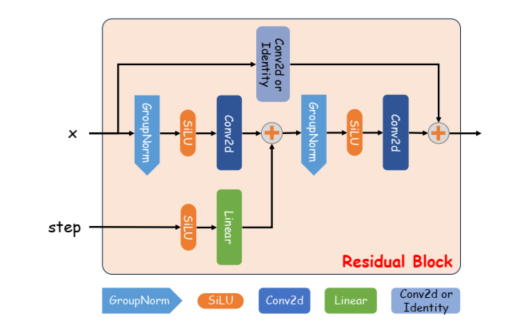

###Unet

#### UNET_ResidualBlock

In [ ]:
# block “biết” đang ở bước nhiễu nào để gỡ nhiễu mạnh hay nhẹ.
# dùng với time_embedding


class UNET_ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim=1280):
        super().__init__()
        self.gn_feature = nn.GroupNorm(32, in_channels)
        self.conv_feature = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.time_embedding_proj = nn.Linear(time_dim, out_channels)

        self.gn_merged = nn.GroupNorm(32, out_channels)
        self.conv_merged = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        # Nếu số kênh không đổi, dùng Identity. Ngược lại, thêm conv để biến đổi số kênh
        self.residual_connection = (
            nn.Identity() if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        )

    def forward(self, input_feature, time_emb):
        residual = input_feature

        # Tiền xử lý input (chuẩn hóa + kích hoạt + conv)
        h = self.gn_feature(input_feature)
        h = F.silu(h)
        h = self.conv_feature(h)

        # Dự phóng embedding thời gian và reshape để cộng vào ảnh
        time_emb_processed = F.silu(time_emb)
        time_emb_projected = self.time_embedding_proj(time_emb_processed)
        time_emb_projected = time_emb_projected.unsqueeze(-1).unsqueeze(-1)

        # Cộng thêm thông tin thời gian, chuẩn hóa và conv tiếp
        merged_feature = h + time_emb_projected
        merged_feature = self.gn_merged(merged_feature)
        merged_feature = F.silu(merged_feature)
        merged_feature = self.conv_merged(merged_feature)

        # Cộng thêm shortcut residual
        output = merged_feature + self.residual_connection(residual)
        return output


#### UNET_AttentionBlock

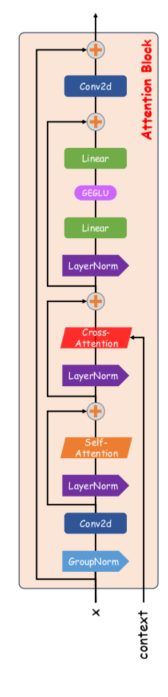

In [ ]:
# Lớp học cách “đặt” vùng ảnh phù hợp với từng token:
# điều‑kiện hoá prompt

class UNET_AttentionBlock(nn.Module):
    def __init__(self, num_heads, head_dim, context_dim=512):
        super().__init__()

        # embed_dim là số muilti nhân với head dim
        embed_dim = num_heads * head_dim

        self.gn_in = nn.GroupNorm(32, embed_dim, eps=1e-6)
        self.proj_in = nn.Conv2d(embed_dim, embed_dim, kernel_size=1, padding=0)

        self.ln_1 = nn.LayerNorm(embed_dim)
        self.attn_1 = SelfAttention(num_heads, embed_dim, in_proj_bias=False)

        self.ln_2 = nn.LayerNorm(embed_dim)
        self.attn_2 = CrossAttention(num_heads, embed_dim, context_dim, in_proj_bias=False)

        self.ln_3 = nn.LayerNorm(embed_dim) #(x)
        self.ffn_geglu = nn.Linear(embed_dim, 4 * embed_dim * 2) #(x, 8x)
        self.ffn_out = nn.Linear(4 * embed_dim, embed_dim) #(4x, x)
        self.proj_out = nn.Conv2d(embed_dim, embed_dim, kernel_size=1, padding=0)

    def forward(self, input_tensor, context_tensor):
        skip_connection = input_tensor
        B, C, H, W = input_tensor.shape
        HW = H * W

        h = self.gn_in(input_tensor)
        h = self.proj_in(h)
        h = h.view(B, C, HW).transpose(-1, -2)  # [B, HW, C]

        attn1_skip = h
        h = self.ln_1(h)
        h = self.attn_1(h)
        h = h + attn1_skip  # Self-attention residual

        attn2_skip = h
        h = self.ln_2(h)
        h = self.attn_2(h, context_tensor)
        h = h + attn2_skip  # Cross-attention residual

        ffn_skip = h
        h = self.ln_3(h)
        intermediate, gate = self.ffn_geglu(h).chunk(2, dim=-1)
        h = intermediate * F.gelu(gate)
        h = self.ffn_out(h)
        h = h + ffn_skip  # FFN residual

        h = h.transpose(-1, -2).view(B, C, H, W)
        output = self.proj_out(h) + skip_connection  # Final residual
        return output


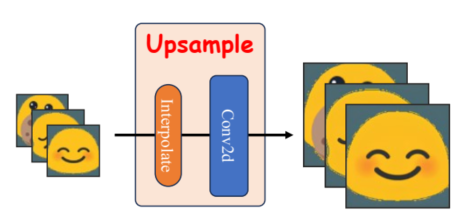

#### UNET

In [ ]:
class Upsample(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.conv = nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1)

    def forward(self, feature_map):
        x = F.interpolate(feature_map, scale_factor=2, mode='nearest')
        x = self.conv(x)
        return x


In [ ]:
class UNET(nn.Module):
    def __init__(self, h_dim, n_head):
        super().__init__()

        self.down_blocks = nn.ModuleList([
            SwitchSequential(nn.Conv2d(4, h_dim, kernel_size=3, padding=1)),
            SwitchSequential(
                UNET_ResidualBlock(h_dim, h_dim),
                UNET_AttentionBlock(n_head, (h_dim)//n_head)
            ),
            SwitchSequential(
                UNET_ResidualBlock(h_dim, h_dim),
                UNET_AttentionBlock(n_head, (h_dim)//n_head)
            ),
            SwitchSequential(nn.Conv2d(h_dim, h_dim, kernel_size=3, stride=2, padding=1)),
            SwitchSequential(
                UNET_ResidualBlock(h_dim, 2*h_dim),
                UNET_AttentionBlock(n_head, (2*h_dim)//n_head)
            ),
            SwitchSequential(
                UNET_ResidualBlock(2*h_dim, 2*h_dim),
                UNET_AttentionBlock(n_head, (2*h_dim)//n_head)
            ),
            SwitchSequential(nn.Conv2d(2*h_dim, 2*h_dim, kernel_size=3, stride=2, padding=1)),
            SwitchSequential(UNET_ResidualBlock(2*h_dim, 4*h_dim)),
            SwitchSequential(UNET_ResidualBlock(4*h_dim, 4*h_dim)),
        ])

        self.mid_block = SwitchSequential(
            UNET_ResidualBlock(4*h_dim, 4*h_dim),
            UNET_AttentionBlock(n_head, (4*h_dim)//n_head),
            UNET_ResidualBlock(4*h_dim, 4*h_dim),
        )

        self.up_blocks = nn.ModuleList([
            SwitchSequential(UNET_ResidualBlock(4*h_dim + 4*h_dim, 4*h_dim)),
            SwitchSequential(UNET_ResidualBlock(4*h_dim + 4*h_dim, 4*h_dim)),
            SwitchSequential(
                UNET_ResidualBlock(4*h_dim + 2*h_dim, 4*h_dim),
                Upsample(4*h_dim)
            ),
            SwitchSequential(
                UNET_ResidualBlock(4*h_dim + 2*h_dim, 2*h_dim),
                UNET_AttentionBlock(n_head, (2*h_dim)//n_head)
            ),
            SwitchSequential(
                UNET_ResidualBlock(4*h_dim, 2*h_dim),
                UNET_AttentionBlock(n_head, (2*h_dim)//n_head)
            ),
            SwitchSequential(
                UNET_ResidualBlock(2*h_dim + h_dim, 2*h_dim),
                UNET_AttentionBlock(n_head, (2*h_dim)//n_head),
                Upsample(2*h_dim)
            ),
            SwitchSequential(
                UNET_ResidualBlock(2*h_dim + h_dim, h_dim),
                UNET_AttentionBlock(n_head, h_dim//n_head)
            ),
            SwitchSequential(
                UNET_ResidualBlock(2*h_dim, h_dim),
                UNET_AttentionBlock(n_head, h_dim//n_head)
            ),
            SwitchSequential(
                UNET_ResidualBlock(2*h_dim, h_dim),
                UNET_AttentionBlock(n_head, h_dim//n_head)
            ),
        ])

    def forward(self, latent_input, context_embedding, time_embedding):
        down_block_residuals = []
        current_feature_map = latent_input #z_t

        for block in self.down_blocks:
            current_feature_map = block(
                current_feature_map,
                context_embedding,
                time_embedding
            )
            down_block_residuals.append(current_feature_map)

        current_feature_map = self.mid_block(
            current_feature_map,
            context_embedding,
            time_embedding
        )

        for block in self.up_blocks:
            residual = down_block_residuals.pop()
            current_feature_map = torch.cat((current_feature_map, residual), dim=1)
            current_feature_map = block(
                current_feature_map,
                context_embedding,
                time_embedding
            )

        return current_feature_map


class UNETOutputLayer(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.final_groupnorm = nn.GroupNorm(32, input_channels)
        self.final_conv = nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1)

    def forward(self, feature_map):
        norm_map = self.final_groupnorm(feature_map)
        activated_map = F.silu(norm_map)
        output_map = self.final_conv(activated_map)

        return output_map

###Timestep handling

In [ ]:
#UNET_ResidualBlock cần time_embedding vì:
#Biết thời điểm đang xử lý trong quy trình khử nhiễu
#Giúp mỗi block hoạt động có “ý thức về thời gian”
class SwitchSequential(nn.Sequential):
    def forward(self, x, guidance_context, time_embedding):
        for module_instance in self:
            if isinstance(module_instance, UNET_AttentionBlock):
                x = module_instance(x, guidance_context)
            elif isinstance(module_instance, UNET_ResidualBlock):
                x = module_instance(x, time_embedding)
            else:
                x = module_instance(x)
        return x


# embedding thời gian
class TimeEmbedding(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.proj1 = nn.Linear(n_embd, 4 * n_embd)
        self.proj2 = nn.Linear(4 * n_embd, 4 * n_embd)

    def forward(self, x):
        x = self.proj1(x)
        x = F.silu(x)
        x = self.proj2(x)
        return x

In [ ]:
# xậy dưng hàm mã hóa thông tin thời gian
def embed_a_timestep(timestep, embedding_dim=320):
  half_dim = embedding_dim // 2
  freqs = torch.exp(-math.log(10000) * torch.arange(start=0, end=half_dim,
                                                    dtype=torch.float32) / half_dim)
  x = torch.tensor(timestep[:, None].float()) * freqs[None]
  embedding = torch.cat([torch.cos(x), torch.sin(x)], dim=-1)
  return embedding

def embed_timesteps(timesteps, embedding_dim=320):
  half_dim = embedding_dim // 2
  freqs = torch.exp(-torch.log(torch.tensor(10000.0)) *
                    torch.arange(half_dim, dtype=torch.float32) / half_dim).to(device=timesteps.device)
  args = timesteps[:, None].float() * freqs[None, :]  # [B, half_dim]
  return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)  # [B, embedding_dim]

#


###Xây dựng hàm diffusion

In [ ]:
class Diffusion(nn.Module):
    def __init__(self, h_dim=128, n_head=4):
        super().__init__()
        self.time_embedding = TimeEmbedding(320)                 # Tạo vector thời gian để đưa vào UNet
        self.unet = UNET(h_dim, n_head)                          # UNet chính gồm Attention và Residual blocks
        self.unet_output = UNETOutputLayer(h_dim, 4)            # Lớp đầu ra, tạo output 4 kênh (thường: mean, var, v.v.)

    @torch.autocast(
        device_type='cuda', dtype=torch.float16,
        enabled=True, cache_enabled=True
    )
    def forward(self, latent, context, time):
        time = self.time_embedding(time)                         # Encode thời gian vào vector
        output = self.unet(latent, context, time)               # Truyền qua UNet chính
        output = self.unet_output(output)                       # Dự đoán đầu ra từ UNet
        return output


### Xây dựng class clip cho mô hình

In [ ]:
class CLIPTextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        #CLIP học cách “hiểu” nội dung ảnh và câu mô tả tương ứng
        CLIP_id = "openai/clip-vit-base-patch32"
        self.tokenizer = CLIPTokenizer.from_pretrained(CLIP_id)
        #CLIPTextEncoder giúp mã hóa prompt thành vector để dùng trong Cross-Attention → từ đó ảnh sẽ mang đúng nội dung mô tả.
        self.text_encoder = CLIPTextModel.from_pretrained(CLIP_id)
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        for param in self.text_encoder.parameters():
            param.requires_grad = False

        self.text_encoder.eval()
        self.text_encoder.to(self.device)

    def forward(self, prompts):
        inputs = self.tokenizer(
            prompts,
            padding="max_length",
            truncation=True,
            max_length=self.text_encoder.config.max_position_embeddings,
            return_tensors="pt"
        )
        input_ids = inputs.input_ids.to(self.device)
        attention_mask = inputs.attention_mask.to(self.device)

        with torch.no_grad():
            text_encoder_output = self.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        last_hidden_states = text_encoder_output.last_hidden_state

        return last_hidden_states

###VAE - Variational Autoencoder

In [ ]:
VAE_id = "stabilityai/sd-vae-ft-mse"
vae = AutoencoderKL.from_pretrained(VAE_id)
vae.requires_grad_(False)
vae.eval()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

## xây dựng các hàm tiện ích xung quanh

In [ ]:
def show_images(images, title="", titles=[]):
    # Tạo một figure có kích thước 8x8 inch để hiển thị ảnh
    plt.figure(figsize=(8, 8))

    # Lặp qua tối đa 25 ảnh và hiển thị chúng
    for i in range(min(25, len(images))):
        plt.subplot(5, 5, i + 1)  # Chia figure thành lưới 5x5 và chọn ô thứ i+1

        # Chuyển tensor ảnh sang numpy, và chuyển từ [C, H, W] thành [H, W, C]
        img = images[i].permute(1, 2, 0).cpu().numpy()

        # Hiển thị ảnh bằng imshow
        plt.imshow(img)

        # Nếu có tiêu đề riêng cho từng ảnh thì thêm vào
        if titles:
            plt.title(titles[i])

        # Tắt trục tọa độ để giao diện gọn gàng hơn
        plt.axis('off')

    # Thêm tiêu đề chính cho toàn bộ grid ảnh
    plt.suptitle(title)

    # Căn chỉnh layout để không bị chồng lên nhau
    plt.tight_layout()

    # Hiển thị hình ảnh
    plt.show()

def rescale(value, in_range, out_range, clamp=False):
    in_min, in_max = in_range
    out_min, out_max = out_range

    in_span = in_max - in_min
    out_span = out_max - out_min

    scaled_value = (value - in_min) / (in_span + 1e-8)
    rescaled_value = out_min + (scaled_value * out_span)

    if clamp:
        # Đảm bảo giá trị nằm trong khoảng [out_min, out_max]
        # Hữu ích khi muốn đảm bảo ảnh hiển thị không vượt giới hạn màu (0–1)
        rescaled_value = torch.clamp(rescaled_value, out_min, out_max)

    return rescaled_value

## Xây dựng dataset

In [ ]:
WIDTH, HEIGHT = 32, 32
batch_size =  4

class EmojiDataset(Dataset):
    def __init__(self, csv_files, image_folder, transform=None):
        self.dataframe = pd.concat([pd.read_csv(csv_file) for csv_file in csv_files])
        self.image_folder = image_folder
        self.dataframe['image_path'] = self.dataframe['file_name'].str.replace('\\', '/')
        self.image_paths = self.dataframe['image_path'].tolist()
        self.titles = self.dataframe['prompt'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    # Hàm này giúp nạp ảnh từ file và đưa vào mạng
    def __getitem__(self, idx):
        # Lấy đường dẫn đầy đủ đến ảnh từ thư mục và danh sách tên ảnh
        image_path = self.image_folder + '/' + self.image_paths[idx]

        # Lấy tiêu đề tương ứng với ảnh và loại bỏ ký tự đặc biệt
        title = self.titles[idx]
        title = title.replace('"', '').replace("'", '')  # Loại bỏ dấu nháy kép và đơn

        # Mở ảnh và chuyển sang chế độ RGB (3 kênh màu) 0
        image = Image.open(image_path).convert('RGB')

        # Nếu có định nghĩa transform (biến đổi ảnh) thì áp dụng vào ảnh
        if self.transform:
            image = self.transform(image)

        # Trả về ảnh đã xử lý và tiêu đề đi kèm
        return image, title

In [ ]:
transform = transforms.Compose([
    transforms.Resize((WIDTH, HEIGHT)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
csv_files = ['/content/blobs_crawled_data/metadata.csv']
image_folder = '/content/blobs_crawled_data/images'


train_dataset = EmojiDataset(
    csv_files=csv_files,
    image_folder=image_folder,
    transform=transform
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

In [ ]:
# lấy batch đầu tiên trong train
dataiter = iter(train_dataloader)
images, titles = next(dataiter)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Batch images shape: torch.Size([4, 3, 32, 32])
blobcat_Roll emoji with a round head, small black eyes, slightly open mouth, neutral expression, orange skin color, no action, with a white background.
Blob_Nuzzle emoji with a round head, closed eyes, small mouth, content expression, yellow skin color, no action, with a white background.
Pride Blob emoji with a round head, small black eyes, winking mouth, happy expression, yellow skin color, no action, with a white background.
Blobhaj_Glare emoji with a rounded head, black oval eyes, small curved mouth, sad expression, white skin color, no action, with a white background.


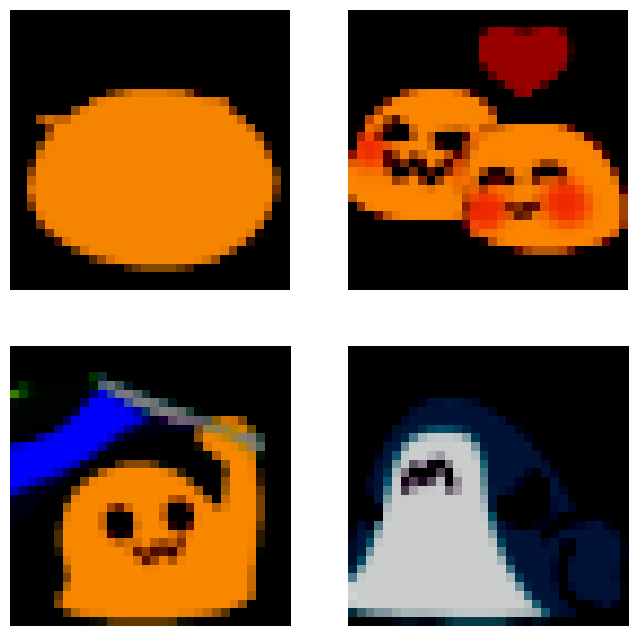

In [ ]:
print(f"Batch images shape: {images.shape}")

clipped_images = torch.clamp(images, 0, 1)
plt.figure(figsize=(8, 8))

# Change loop range to the actual batch size
for i in range(images.shape[0]): # images.shape[0] gives the batch size
    plt.subplot(2, 2, i + 1)  # Adjust subplot grid if necessary
    plt.imshow(clipped_images[i].permute(1, 2, 0).numpy())
    print(titles[i])
    plt.axis('off')
plt.show()

## Model Training

In [ ]:
    def train(diffusion, vae, text_encoder, scheduler,
              optimizer, lr_scheduler, scaler,
              criterion, dataloader, num_epochs, device="cuda"):
        losses = []
        for epoch in range(num_epochs):
            diffusion.train()  # Đặt mô hình diffusion vào chế độ huấn luyện

            epoch_loss = 0.0
            progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

            for batch_idx, (images, titles) in enumerate(progress_bar):
                images = images.to(device)

                # Tạo prompt text từ tiêu đề ảnh
                image_titles = [f"A photo of {title}" for title in titles]

                # 50% số prompt sẽ bị bỏ rỗng để mô hình học cách sinh ảnh không điều kiện
                image_titles = [title if random.random() < 0.5 else "" for title in image_titles]

                # Mã hóa ảnh sang latent space bằng VAE và chuẩn hóa
                with torch.no_grad():
                    # nén ảnh xuống hệ số 8 mỗi chiều và dùng 4 kênh latent
                    # images=(1, 3, 512, 512)	->  latents=(1, 4, 64, 64)
                    latents = vae.encode(images).latent_dist.sample() * 0.18215

                # Sinh ngẫu nhiên các bước thời gian t để thêm nhiễu (mục đích để học được cho các bước ngẫu nhiên)
                # t được lấy ngẫu nhiên (thường là phân bố đều) ở mỗi batch.
                timesteps = torch.randint(
                    0, scheduler.total_train_timesteps,
                    (latents.shape[0],), device=device
                )

                # Thêm nhiễu vào latent tại timestep t
                # như vậy hàm này trả về zt và nhiễu epsilon
                noisy_latents, noise = scheduler.add_noise(latents, timesteps)

                # Mã hóa thông tin thời gian và văn bản thành embedding
                time_embeddings = embed_timesteps(timesteps).to(device)
                text_embeddings = text_encoder(image_titles)

                # Dự đoán nhiễu với latent bị nhiễu (zt) + text + thời gian
                noise_pred = diffusion(noisy_latents, text_embeddings, time_embeddings)

                # Tính loss giữa nhiễu dự đoán và nhiễu thật
                # Đây là context manager từ torch.cuda.amp (Automatic Mixed Precision):
                # Tự động chọn giữa float32 và float16 trong quá trình tính toán
                # Tối ưu cho GPU hỗ trợ Tensor Cores (như RTX hoặc A100)
                with autocast(device_type='cuda', dtype=torch.float16,
                              enabled=True, cache_enabled=True):
                    loss = criterion(noise_pred, noise)

                # Cập nhật mô hình
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                batch_loss = loss.item()
                epoch_loss += batch_loss

                # Hiển thị loss và learning rate trên progress bar
                progress_bar.set_postfix(loss=f"{batch_loss:.5f}",
                                         lr=f"{optimizer.param_groups[0]['lr']:.6f}")

            # Cập nhật learning rate
            lr_scheduler.step()

            # Lưu loss trung bình cho epoch hiện tại
            avg_epoch_loss = epoch_loss / len(dataloader)
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] - Avg Loss: {avg_epoch_loss:.5f}")
            losses.append(avg_epoch_loss)

        print("Training finished!")
        return losses


In [ ]:
EPOCHS = 300

h_dim = 384
n_head = 8

vae = vae.to(device)
diffusion = Diffusion(h_dim, n_head).to(device)
clip = CLIPTextEncoder().to(device)

random_generator = torch.Generator(device='cuda')
noise_scheduler = DDPMScheduler(random_generator)

# dùng để tối ưu hóa các tham số trong diffusion (Unet)
optimizer = torch.optim.AdamW(diffusion.parameters(), lr=1e-4)
criterion = torch.nn.MSELoss()

lrate_scheduler = lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)
scaler = GradScaler()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

vae_params = count_parameters(vae)
diffusion_params = count_parameters(diffusion)
clip_params = count_parameters(clip)

print(f"VAE parameters: {vae_params}")
print(f"Diffusion parameters: {diffusion_params}")
print(f"CLIP parameters: {clip_params}")
print(f"Total parameters: {vae_params + diffusion_params + clip_params}")

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

VAE parameters: 83653863
Diffusion parameters: 631718020
CLIP parameters: 63165952
Total parameters: 778537835


In [ ]:
losses = train(diffusion, vae, clip, noise_scheduler,
               optimizer, lrate_scheduler, scaler,
               criterion, train_dataloader, EPOCHS, device=device)

Epoch 1/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Epoch [1/300] - Avg Loss: 0.27827


Epoch 2/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 3/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 4/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be con

Epoch [10/300] - Avg Loss: 0.20294


Epoch 11/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 12/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 13/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be 

Epoch [20/300] - Avg Loss: 0.19993


Epoch 21/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 22/300:   0%|          | 0/1156 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 22/300:  44%|████▍     | 513/1156 [03:32<04:20,  2.47it/s, loss=0.05425, lr=0.000099]

In [ ]:
# vẽ graph hình
plt.figure(figsize=(16, 8))

plt.plot(losses, label='Loss', color='blue')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

min_loss = min(losses)
min_loss_epoch = losses.index(min_loss)
plt.scatter(min_loss_epoch, min_loss, color='green', zorder=5)
plt.text(min_loss_epoch,
         min_loss+0.025,
         f'{min_loss:.4f}',
         fontsize=12,
         verticalalignment='center',
         horizontalalignment='center',
         color='green')

plt.legend()
plt.grid()
plt.savefig('training_loss.png')
plt.show()


# Model Checkpointing

In [ ]:
torch.save(diffusion.state_dict(), "diffusion_model_emoji.pth")
!zip -r diffusion_model_emoji.zip diffusion_model_emoji.pth

In [ ]:
# https://drive.google.com/file/d/1L7NiTeK5veX7A7ynux7vwZjx7b_ta5ur/view?usp=drive_link
!gdown 1L7NiTeK5veX7A7ynux7vwZjx7b_ta5ur

In [ ]:
h_dim = 384
n_head = 8

VAE_id = "stabilityai/sd-vae-ft-mse"
vae = AutoencoderKL.from_pretrained(VAE_id)
vae.requires_grad_(False)
vae.eval()
vae = vae.to(device)

clip = CLIPTextEncoder().to(device)
clip.eval()

diffusion = Diffusion(h_dim, n_head).to(device)
diffusion.load_state_dict(torch.load("diffusion_model_emoji.pth"))
diffusion.eval()

random_generator = torch.Generator(device='cuda')
noise_scheduler = DDPMScheduler(random_generator)

# Image Generation

In [ ]:
LATENTS_WIDTH = WIDTH // 8
LATENTS_HEIGHT = HEIGHT // 8

def generate_image(
    prompt,
    diffusion,
    vae,
    text_encoder,
    scheduler,
    num_inference_steps=100,
    seed=None,
    device='cuda' if torch.cuda.is_available() else 'cpu',
):
    rng_generator = torch.Generator(device=device)
    if seed is None:
        rng_generator.seed()
    else:
        rng_generator.manual_seed(seed)

    prompts = [prompt]
    text_embeddings = text_encoder(prompts).to(device)

    scheduler.set_steps(num_inference_steps)

    latent_shape = (1, 4, LATENTS_HEIGHT, LATENTS_WIDTH)

    noisy_latents = torch.randn(
        latent_shape, generator=rng_generator, device=device)
    timesteps = scheduler.schedule_timesteps

    for t in tqdm(timesteps):
        latent_model_input = noisy_latents

        time_embedding = embed_a_timestep(t).to(device)

        with torch.no_grad():
            noise_pred = diffusion(
                latent_model_input,
                text_embeddings,
                time_embedding
            )
        noisy_latents = scheduler.step(
            t,
            noisy_latents,
            noise_pred
        )

    final_latents = noisy_latents / 0.18215

    with torch.no_grad():
        decoded_image_tensor = vae.decode(final_latents).sample

    image_output = rescale(decoded_image_tensor, (-1, 1), (0, 255), clamp=True)
    image_output = image_output.permute(0, 2, 3, 1).to("cpu", torch.uint8).numpy()
    return image_output[0]

In [ ]:
user_inputs = prompts = [
    "a happy blob emoji with sparkling eyes open mouth showing tongue, green skin, floating, purple background",
    "an angry blob emoji with narrowed eyes frowning mouth, orange skin, wearing a party hat, white background",
    "a confused blob emoji with wide eyes slightly open mouth, yellow skin, pointing at his head and wearing a star-shaped crown, dark blue background",
    "a sad blob emoji with droopy eyes frowning mouth, green skin, waving hand and wearing red pom-poms, white background",
    "a grumpy blob emoji with half-closed eyes frowning mouth, purple skin, wielding a large knife, red background",
    "a happy blob emoji with teary eyes smiling mouth, pink skin, wearing a sombrero, white background",
    "a devilish blob emoji with red eyes wide open mouth showing tongue, red skin, wearing horns and hugging a teddy bear, warm background with a fireplace and autumn leaves",
    "a cozy blob emoji with half-closed eyes slightly open mouth, orange skin, holding a steaming cup of coffee and making a fist, warm background with a fireplace and autumn leaves",
    "a surprised blob emoji with wide eyes open mouth, yellow skin, wearing a purple hoodie and sitting on its hind legs, blue background",
]

fig, axes = plt.subplots(3, 3, figsize=(3, 3))
axes = axes.flatten()
for i, user_input in enumerate(user_inputs[:9]):
    prompt = f"A photo of {user_input.lower()}"
    img = generate_image(prompt, diffusion, vae, clip, noise_scheduler, num_inference_steps=100)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
user_inputs = [
    "a sad blob emoji with droopy eyes, frowning mouth, brown skin, wearing a party hat, red background",
    "a sleepy blob emoji with closed eyes, frowning mouth, green skin, sitting on its hind legs, white background",
    "a curious blob emoji with half-closed eyes, slightly open mouth, yellow skin, pointing finger upwards, dark blue background",
    "a happy blob emoji with bright blue eyes, wide open mouth, green skin, hanging from a string, white background",
    "a confused blob emoji with wide eyes, slightly open mouth, yellow skin, wearing a red bow tie, white background",
    "a grumpy blob emoji with half-closed eyes, wide open mouth showing teeth, yellow skin, light blue background with red hearts around",
    "a happy blob emoji with wide open eyes, smiling mouth, pink skin, sitting on a blue ribbon, white background",
    "a laughing blob emoji with closed eyes, wide open mouth, orange skin, holding a thermometer, white background",
    "a cool blob emoji with sunglasses, smiling mouth, pink skin, wearing horns, purple background",
]

fig, axes = plt.subplots(3, 3, figsize=(3, 3))
axes = axes.flatten()
for i, user_input in enumerate(user_inputs[:9]):
    prompt = f"A photo of {user_input.lower()}"
    img = generate_image(prompt, diffusion, vae, clip, noise_scheduler, num_inference_steps=100)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
user_inputs = [
    "a sleepy blob emoji with closed eyes, smiling mouth, green skin, holding a teddy bear, purple background",
    "an angry blob emoji with wide open eyes, showing teeth, gray skin, wearing a sombrero, red background",
    "a confused blob emoji with wide eyes, slightly open mouth, pink skin, holding a sign that says SIMP, dark blue background",
    "a grumpy blob emoji with half-closed eyes, frowning mouth, green skin, eating popcorn while wearing a sleeping mask, white background",
    "a heart-eyed blob emoji with heart-shaped eyes, open mouth showing tongue, white skin, making a fist, light blue background with red hearts",
    "a sad blob emoji with teary eyes, frowning mouth, yellow skin, wearing sunglasses, black background",
    "a cheerful blob emoji with bright eyes, big smile, green skin, sitting on a swing and wearing a rainbow hat, white background",
    "a curious blob emoji with large, round eyes, slightly open mouth, light brown skin, floating and wearing a blue shirt, purple background",
    "a menacing blob emoji with narrowed eyes, open mouth showing teeth, green skin, hugging a person while wearing a party hat, blue background",
]

fig, axes = plt.subplots(3, 3, figsize=(3, 3))
axes = axes.flatten()
for i, user_input in enumerate(user_inputs[:9]):
    prompt = f"A photo of {user_input.lower()}"
    img = generate_image(prompt, diffusion, vae, clip, noise_scheduler, num_inference_steps=100)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
user_inputs = [
    "a grumpy blob emoji with half-closed eyes, smiling mouth, green skin, wearing a sombrero, red background",
    "a happy blob emoji with wide eyes, frowning mouth, red skin, pointing finger upwards, black background",
    "a sad blob emoji with teary eyes, wide open mouth showing tongue, orange skin, wearing a party hat, purple background",
    "a confused blob emoji with bright blue eyes, slightly open mouth, yellow skin, holding a large knife, white background",
    "a sleepy blob emoji with closed eyes, big smile, pink skin, wearing a rainbow hat, dark blue background",
    "an angry blob emoji with narrowed eyes, licking lips, white skin, sitting on a swing, warm background with fireplace",
    "a cool blob emoji with sunglasses, frowning mouth, purple skin, eating popcorn, light blue background with hearts",
    "a devilish blob emoji with red eyes, smiling mouth, brown skin, holding a steaming cup of coffee, white background",
    "a curious blob emoji with large round eyes, open mouth showing teeth, gray skin, hugging a teddy bear, red background",
]

fig, axes = plt.subplots(3, 3, figsize=(3, 3))
axes = axes.flatten()
for i, user_input in enumerate(user_inputs[:9]):
    prompt = f"A photo of {user_input.lower()}"
    img = generate_image(prompt, diffusion, vae, clip, noise_scheduler, num_inference_steps=100)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


#Test

In [ ]:
import torch
import torch.nn as nn

# Tạo một tensor có batch_size=1, 4 kênh, 2x2 kích thước ảnh
x = torch.tensor([[[[1., 2.],
                    [3., 4.]],

                   [[5., 6.],
                    [7., 8.]],

                   [[9., 10.],
                    [11., 12.]],

                   [[13., 14.],
                    [15., 16.]]]])

print("Input shape:", x.shape)  # [1, 4, 2, 2]

# GroupNorm với 2 nhóm → mỗi nhóm gồm 2 kênh
gn = nn.GroupNorm(num_groups=2, num_channels=4)
out = gn(x)

print("Output shape:", out.shape)
print("Output[0, :, 0, 0]:", out[0, :, 0, 0])  # pixel ở góc trái của từng kênh


In [ ]:
import torch
timesteps = torch.randint(
    0, 100,
    (2,)
)

In [ ]:
timesteps

In [ ]:
import math
def embed_timesteps(timesteps, embedding_dim=10):
    half_dim = embedding_dim // 2
    freqs = torch.exp(-math.log(10000) *
                      torch.arange(half_dim, dtype=torch.float32) /
                      half_dim).to(device=timesteps.device)
    args = timesteps[:, None].float() * freqs[None, :]
    sin_cos = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    return sin_cos, freqs

In [ ]:
embed_timesteps, freqs = embed_timesteps(timesteps)
print(embed_timesteps)
print(freqs)

In [ ]:
# prompt: hãy đưa một ví dụ vớiclip = CLIPTextEncoder().to(device)

import torch
import torch.nn as nn
from transformers import CLIPTextModel, CLIPTokenizer

# Assuming 'device' is defined elsewhere in your code (e.g., device = "cuda" if torch.cuda.is_available() else "cpu")
device = "cuda" if torch.cuda.is_available() else "cpu"

class CLIPTextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        CLIP_id = "openai/clip-vit-base-patch32"
        self.tokenizer = CLIPTokenizer.from_pretrained(CLIP_id)
        self.text_encoder = CLIPTextModel.from_pretrained(CLIP_id)
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        for param in self.text_encoder.parameters():
            param.requires_grad = False

        self.text_encoder.eval()
        self.text_encoder.to(self.device)

        #self.projection1 = nn.Linear(512, 768)  # First projection

    def forward(self, prompts):
        inputs = self.tokenizer(
            prompts,
            #padding="max_length",
            truncation=True,
            max_length=self.text_encoder.config.max_position_embeddings,
            return_tensors="pt"
        )
        input_ids = inputs.input_ids.to(self.device)
        attention_mask = inputs.attention_mask.to(self.device)

        with torch.no_grad():
            text_encoder_output = self.text_encoder(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
        last_hidden_states = text_encoder_output.last_hidden_state
        #last_hidden_states = self.projection1(last_hidden_states)

        return last_hidden_states


# Example usage:
clip = CLIPTextEncoder().to(device)

prompts = ["a photo of a cat", "a photo of a dog"]
text_embeddings = clip(prompts)

print(text_embeddings.shape)  # Output: torch.Size([2, 7, 512])


In [ ]:
!pip install diffusers
from diffusers import AutoencoderKL

VAE_id = "stabilityai/sd-vae-ft-mse"
vae = AutoencoderKL.from_pretrained(VAE_id) # Now, AutoencoderKL is defined
vae.requires_grad_(False)
vae.eval()